# GET THE DATA

### GET DATA with correct class redistribution and one hot encoding

In [1]:
import sys, os
sys.path.insert(0, os.path.join("/Users/eagle/Documents/eagle-classification", "ChannelViT"))
from load_data import Load_Data
from utils import count_data_per_class, convert_labels_to_one_hot, count_data_per_multiclass
num_classes = 7
path_Duramat = "/Users/eagle/FFHS/eagle-bfe - data/Duramat_no_pool_labels.pkl"
# directory_path = os.path.dirname(current_dir)+"/eagle-labelling/features_pickle/"
data_loader =  Load_Data(path_Duramat)
data_Duramat = data_loader.get_data()
label_counts_duramat = count_data_per_class(data_Duramat)
count_data_per_multiclass(data_Duramat)
labels = [item[1] for item in data_Duramat]  # Extract the labels (tensors)
data_Duramat = convert_labels_to_one_hot(data_Duramat, num_classes=num_classes)

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{0: 5877, 1: 3242, 2: 3662, 3: 2179}
{'good': 5877, 'crack': 3242, 'cross': 3662, 'dark': 2179}
{0: 5877, 1: 158, 2: 985, 3: 28, 4: 933, 5: 407, 6: 1744}
{'good': 5877, 'crack': 158, 'cross': 985, 'dark': 28, 'crack&cross': 933, 'crack&dark': 407, 'crack&cross&dark': 1744}


# GET MODEL

In [2]:
from load_data import just_transform
tensor_label_list_Duramat = just_transform(data_Duramat, channels=[0])
from sklearn.model_selection import train_test_split

# Build stratify labels (convert one-hot / multi-hot tensors to class index via argmax)
stratify_labels = []
for _, lbl in tensor_label_list_Duramat:
	# support torch tensors and numpy arrays / lists
	if hasattr(lbl, "argmax"):
		# torch tensor -> use .argmax().item()
		try:
			stratify_labels.append(int(lbl.argmax().item()))
		except Exception:
			stratify_labels.append(int(lbl.argmax()))
	else:
		import numpy as _np
		stratify_labels.append(int(_np.argmax(lbl)))

train_data, val_data = train_test_split(
	tensor_label_list_Duramat,
	test_size=0.3,
	random_state=42,
	stratify=stratify_labels
)

# lists don't have .shape -> show lengths instead
len(train_data), len(val_data)




Preprocessing images: 100%|██████████| 10132/10132 [00:14<00:00, 684.53it/s] 


(7092, 3040)

In [18]:
# ...existing code...
import sys
import argparse
import re
import os
import torch

def parse_args():
    parser = argparse.ArgumentParser(description="Train and evaluate the model.")
    parser.add_argument('--num_train_epochs', type=int, default=37, help='Number of training epochs.')
    parser.add_argument('--batch_size', type=int, default=13, help='Batch size for training and evaluation.')
    parser.add_argument('--retrain', type=str, default='predict_only', choices=['retrain', 'resume', 'predict_only'], help='Choose training mode: retrain, resume, or predict_only.')
    parser.add_argument('--use_only_EL', action='store_true', default=False, help='Use only EL images.')
    parser.add_argument('--all_colors', action='store_true', default=True, help='Use all available channels.')
    parser.add_argument('--num_classes', type=int, default=7, help='Number of classes.')     
    parser.add_argument('--init_weights_name', type=str, default='imagenet_channelvit_small_p16_with_hcs_supervised', help='Name of the initial weights file.')

    # In a notebook, avoid parsing the outer IPython argv — use an empty list.
    if ('ipykernel' in sys.modules) or ('get_ipython' in globals()):
        args = parser.parse_args([])   # safe for notebook
    else:
        args = parser.parse_args()

    def extract_number_from_name(name):
        match = re.search(r'p(\d+)', name)
        if match:
            return int(match.group(1))
        else:
            raise ValueError("No number found in the name")

    args.patch_size = extract_number_from_name(args.init_weights_name)
    return args


def setup_config(args):
    config = {}
    # __file__ is not defined inside notebooks — fall back to cwd when needed
    try:
        base = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
    except NameError:
        base = os.getcwd()
    config['current_dir'] = base

    config['device'] = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    config['output_model_folder'] = os.path.join(f'/Data/models/model_with_{args.init_weights_name}/epochs_{args.num_train_epochs}/')
    config['input_model_folder'] = os.path.join('/Data/models/')
    config['images_folder'] = os.path.join(config['current_dir'], 'Data/images/')
    config['path_Website'] = "/Users/eagle/Library/CloudStorage/OneDrive-SharedLibraries-FFHS/eagle-bfe - data/Webpage"

    config['name_flag'] = 'rgb' if args.all_colors else 'gray'
    if args.use_only_EL:
        config['channels'] = [0]
    else:
        config['channels'] = [0,1,2,3,4,5,6] if args.all_colors else [0,1,2]

    if args.init_weights_name == 'imagenet_channelvit_small_p16_with_hcs_supervised':
        config['max_channels'] = 3
    elif args.init_weights_name == 'so2sat_channelvit_small_p8_with_hcs_hard_split_supervised':
        config['max_channels'] = 18 
    elif args.init_weights_name == 'cpjump_cellpaint_bf_channelvit_small_p8_with_hcs_supervised':
        config['max_channels'] = 8 
    elif args.init_weights_name == 'camelyon_channelvit_small_p8_with_hcs_supervised':
        config['max_channels'] = 3 
    else:
        raise ValueError(f"Unknown init_weights_name: {args.init_weights_name}. Please set max_channels accordingly.")
    
    return config

args = parse_args()
config = setup_config(args)
print(config)
print(args)
# ...existing code...

{'current_dir': '/Users/eagle/Documents/eagle-classification', 'device': device(type='mps'), 'output_model_folder': '/Data/models/model_with_imagenet_channelvit_small_p16_with_hcs_supervised/epochs_37/', 'input_model_folder': '/Data/models/', 'images_folder': '/Users/eagle/Documents/eagle-classification/Data/images/', 'path_Website': '/Users/eagle/Library/CloudStorage/OneDrive-SharedLibraries-FFHS/eagle-bfe - data/Webpage', 'name_flag': 'rgb', 'channels': [0, 1, 2, 3, 4, 5, 6], 'max_channels': 3}
Namespace(num_train_epochs=37, batch_size=13, retrain='predict_only', use_only_EL=False, all_colors=True, num_classes=7, init_weights_name='imagenet_channelvit_small_p16_with_hcs_supervised', patch_size=16)


In [19]:
from load_data import PVDataset, get_train_transforms, get_val_transforms
val_transforms = get_val_transforms()

dataset_train_1channel = PVDataset(train_data, channels=[[0]] * len(train_data), scale=1, return_labels=True, transform=val_transforms)
dataset_val_1channel = PVDataset(val_data, channels=[[0]] * len(val_data), scale=1, return_labels=True, transform=val_transforms)

In [20]:
dataset_train_1channel[0]

{'images': tensor([[[-3.6943, -3.6943, -3.6943,  ..., -3.7174, -3.7174, -3.7174],
          [-3.6943, -3.6943, -3.6943,  ..., -3.7174, -3.6943, -3.6943],
          [-3.6943, -3.6943, -3.6943,  ..., -3.7174, -3.7174, -3.7174],
          ...,
          [-2.6332, -2.6332, -2.5871,  ..., -2.3795, -2.4025, -2.3333],
          [-2.7024, -2.6563, -2.6332,  ..., -2.3795, -2.3795, -2.3564],
          [-2.6332, -2.5640, -2.5871,  ..., -2.3333, -2.2872, -2.2872]]]),
 'labels': tensor([0., 1., 0., 0., 0., 0., 0.]),
 'channels': tensor([0])}

# TRAIN

In [21]:
from ChannelViT.training_multi_one_input_type import retrain_resume_or_load_pretrained
args.max_channels=3
trainer = retrain_resume_or_load_pretrained(
    args, 
    config['current_dir'], 
    config['input_model_folder'], 
    config['device'], 
    config['output_model_folder'], 
    concat_train=dataset_train_1channel, 
    concat_val=dataset_val_1channel,
    channels=config['channels'], 
    name_flag=config['name_flag'] + 'Duramat'
)

Warning!!!
Samplev2 channel vit randomly sample channels for each batch.
It is only compatible with Supervised learning
Doesn't work with DINO or Linear Prob


/Users/eagle/Documents/eagle-classification/ChannelViT/training_multi_one_input_type.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f

Found checkpoints, loading the latest one.
Trainer state restored from /Users/eagle/Documents/eagle-classification/Data/models/model_with_imagenet_channelvit_small_p16_with_hcs_supervised/epochs_37/checkpoint-5809


/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# PREDICT

In [56]:
predictions = trainer.predict(dataset_val_1channel) 
predlabels = predictions.predictions.argmax(axis=-1)
predictions.metrics


/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'test_accuracy': 0.9838815789473684,
 'test_f1': 0.994272924458776,
 'test_loss': 0.011321312747895718,
 'test_runtime': 6.8752,
 'test_samples_per_second': 442.166,
 'test_steps_per_second': 34.035}

In [39]:
import numpy as np
label_names  =  {  0: 'good',
            1: 'crack',
            2: 'cross',
            3: 'dark',
            4: 'corrosion',
            5: 'discoloration',
            6: 'delamination',
        }
num_labels = 7
# Evaluation cell - uses existing variables: predictions, num_labels, label_names (dict)
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_fscore_support, hamming_loss,
                             multilabel_confusion_matrix, accuracy_score, roc_auc_score)

# prepare predictions and ground truth
logits = predictions.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]
probs = 1.0 / (1.0 + np.exp(-logits))
preds = (probs > 0.5).astype(int)
true = predictions.label_ids.astype(int)

# overall multi-label metrics
metrics = {
    "f1_micro": f1_score(true, preds, average="micro"),
    "f1_macro": f1_score(true, preds, average="macro"),
    "precision_micro": precision_score(true, preds, average="micro", zero_division=0),
    "recall_micro": recall_score(true, preds, average="micro", zero_division=0),
    "hamming_loss": hamming_loss(true, preds),
    "subset_accuracy": float(np.mean(np.all(true == preds, axis=1))),
}
print("Overall metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# per-class precision/recall/f1/support
prec, rec, f1, sup = precision_recall_fscore_support(true, preds, average=None, zero_division=0)
print("\nPer-class metrics:")
for i in range(num_labels):
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  precision={prec[i]:.3f}  recall={rec[i]:.3f}  f1={f1[i]:.3f}  support={int(sup[i])}")

# per-class confusion components (TN, FP, FN, TP)
mlcm = multilabel_confusion_matrix(true, preds)
print("\nPer-class confusion (TN, FP, FN, TP):")
for i, cm in enumerate(mlcm):
    tn, fp, fn, tp = cm.ravel()
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  TN={tn:5d}  FP={fp:5d}  FN={fn:5d}  TP={tp:5d}")

# top-1 accuracy on examples that are single-label in ground truth
single_mask = (true.sum(axis=1) == 1)
if single_mask.any():
    true_single = true[single_mask].argmax(axis=1)
    pred_single = preds[single_mask].argmax(axis=1)
    top1_acc = accuracy_score(true_single, pred_single)
    print(f"\nTop-1 accuracy on single-label examples: {top1_acc:.4f}  (n={int(single_mask.sum())})")
else:
    print("\nNo single-label examples found for top-1 accuracy.")

# try ROC-AUC per class if applicable
try:
    aucs = []
    for i in range(num_labels):
        # require both positive and negative labels for AUC
        if len(np.unique(true[:, i])) > 1:
            aucs.append(roc_auc_score(true[:, i], probs[:, i]))
        else:
            aucs.append(np.nan)
    print("\nPer-class ROC AUC:")
    for i, a in enumerate(aucs):
        name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
        print(f"  [{i}] {name:12s}  AUC={a if np.isnan(a) else f'{a:.4f}'}")
except Exception as e:
    print("\nROC AUC skipped due to error:", e)

Overall metrics:
  f1_micro: 0.9943
  f1_macro: 0.5667
  precision_micro: 0.9964
  recall_micro: 0.9922
  hamming_loss: 0.0024
  subset_accuracy: 0.9839

Per-class metrics:
  [0] good          precision=0.998  recall=1.000  f1=0.999  support=1763
  [1] crack         precision=0.999  recall=0.997  f1=0.998  support=973
  [2] cross         precision=0.997  recall=0.990  f1=0.994  support=1109
  [3] dark          precision=0.986  recall=0.967  f1=0.976  support=637
  [4] corrosion     precision=0.000  recall=0.000  f1=0.000  support=0
  [5] discoloration  precision=0.000  recall=0.000  f1=0.000  support=0
  [6] delamination  precision=0.000  recall=0.000  f1=0.000  support=0

Per-class confusion (TN, FP, FN, TP):
  [0] good          TN= 1274  FP=    3  FN=    0  TP= 1763
  [1] crack         TN= 2066  FP=    1  FN=    3  TP=  970
  [2] cross         TN= 1928  FP=    3  FN=   11  TP= 1098
  [3] dark          TN= 2394  FP=    9  FN=   21  TP=  616
  [4] corrosion     TN= 3040  FP=    0  FN= 

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# LOAD TRAINING

In [8]:
from ChannelViT.training_multi_one_input_type import retrain_resume_or_load_pretrained
args.max_channels=3
args.retrain='predict_only'
trainer_from_file = retrain_resume_or_load_pretrained(
    args, 
    config['current_dir'], 
    config['input_model_folder'], 
    config['device'], 
    config['output_model_folder'], 
    concat_train=dataset_train_1channel, 
    concat_val=dataset_val_1channel,
    channels=config['channels'], 
    name_flag=config['name_flag'] + 'Duramat'
)
predictions_from_file = trainer_from_file.predict(dataset_val_1channel) 
predlabels = predictions_from_file.predictions.argmax(axis=-1)
print(predictions_from_file.metrics)

Warning!!!
Samplev2 channel vit randomly sample channels for each batch.
It is only compatible with Supervised learning
Doesn't work with DINO or Linear Prob
Found checkpoints, loading the latest one.
Trainer state restored from /Users/eagle/Documents/eagle-classification/Data/models/model_with_imagenet_channelvit_small_p16_with_hcs_supervised/epochs_37/checkpoint-5809


/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'test_model_preparation_time': 0.0013, 'test_accuracy': 0.7888157894736842, 'test_f1': 0.8565360558107189, 'test_loss': 0.3862709403038025, 'test_runtime': 9.0869, 'test_samples_per_second': 334.546, 'test_steps_per_second': 25.751}


In [10]:
num_labels=7
import numpy as np
label_names  =  {  0: 'good',
            1: 'crack',
            2: 'cross',
            3: 'dark',
            4: 'corrosion',
            5: 'discoloration',
            6: 'delamination',
        }

# Evaluation cell - uses existing variables: predictions, num_labels, label_names (dict)
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_fscore_support, hamming_loss,
                             multilabel_confusion_matrix, accuracy_score, roc_auc_score)

# prepare predictions and ground truth
logits = predictions_from_file.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]
probs = 1.0 / (1.0 + np.exp(-logits))
preds = (probs > 0.5).astype(int)
true = predictions_from_file.label_ids.astype(int)

# overall multi-label metrics
metrics = {
    "f1_micro": f1_score(true, preds, average="micro"),
    "f1_macro": f1_score(true, preds, average="macro"),
    "precision_micro": precision_score(true, preds, average="micro", zero_division=0),
    "recall_micro": recall_score(true, preds, average="micro", zero_division=0),
    "hamming_loss": hamming_loss(true, preds),
    "subset_accuracy": float(np.mean(np.all(true == preds, axis=1))),
}
print("Overall metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# per-class precision/recall/f1/support
prec, rec, f1, sup = precision_recall_fscore_support(true, preds, average=None, zero_division=0)
print("\nPer-class metrics:")
for i in range(num_labels):
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  precision={prec[i]:.3f}  recall={rec[i]:.3f}  f1={f1[i]:.3f}  support={int(sup[i])}")

# per-class confusion components (TN, FP, FN, TP)
mlcm = multilabel_confusion_matrix(true, preds)
print("\nPer-class confusion (TN, FP, FN, TP):")
for i, cm in enumerate(mlcm):
    tn, fp, fn, tp = cm.ravel()
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  TN={tn:5d}  FP={fp:5d}  FN={fn:5d}  TP={tp:5d}")

# top-1 accuracy on examples that are single-label in ground truth
single_mask = (true.sum(axis=1) == 1)
if single_mask.any():
    true_single = true[single_mask].argmax(axis=1)
    pred_single = preds[single_mask].argmax(axis=1)
    top1_acc = accuracy_score(true_single, pred_single)
    print(f"\nTop-1 accuracy on single-label examples: {top1_acc:.4f}  (n={int(single_mask.sum())})")
else:
    print("\nNo single-label examples found for top-1 accuracy.")

# try ROC-AUC per class if applicable
try:
    aucs = []
    for i in range(num_labels):
        # require both positive and negative labels for AUC
        if len(np.unique(true[:, i])) > 1:
            aucs.append(roc_auc_score(true[:, i], probs[:, i]))
        else:
            aucs.append(np.nan)
    print("\nPer-class ROC AUC:")
    for i, a in enumerate(aucs):
        name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
        print(f"  [{i}] {name:12s}  AUC={a if np.isnan(a) else f'{a:.4f}'}")
except Exception as e:
    print("\nROC AUC skipped due to error:", e)


Overall metrics:
  f1_micro: 0.9218
  f1_macro: 0.4278
  precision_micro: 0.9982
  recall_micro: 0.8563
  hamming_loss: 0.0306
  subset_accuracy: 0.7882

Per-class metrics:
  [0] good          precision=0.997  recall=0.999  f1=0.998  support=1763
  [1] crack         precision=0.999  recall=1.000  f1=0.999  support=973
  [2] cross         precision=0.999  recall=0.995  f1=0.997  support=1109
  [3] dark          precision=0.000  recall=0.000  f1=0.000  support=637
  [4] corrosion     precision=0.000  recall=0.000  f1=0.000  support=0
  [5] discoloration  precision=0.000  recall=0.000  f1=0.000  support=0
  [6] delamination  precision=0.000  recall=0.000  f1=0.000  support=0

Per-class confusion (TN, FP, FN, TP):
  [0] good          TN= 1272  FP=    5  FN=    1  TP= 1762
  [1] crack         TN= 2066  FP=    1  FN=    0  TP=  973
  [2] cross         TN= 1930  FP=    1  FN=    6  TP= 1103
  [3] dark          TN= 2403  FP=    0  FN=  637  TP=    0
  [4] corrosion     TN= 3040  FP=    0  FN= 

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Infinity

In [11]:
path_Infinity = "/Users/eagle/Documents//eagle-labelling/features_pickle/Infinity_all_no_pool_labels.pkl"
data_loader =  Load_Data(path_Infinity)
data_Infinity_int = data_loader.get_data()
data_loader.get_label_statistics()
label_counts_infinity = count_data_per_class(data_Infinity_int)
count_data_per_multiclass(data_Infinity_int)

data_Infinity = convert_labels_to_one_hot(data_Infinity_int, num_classes)
tensor_label_list_Infinity = just_transform(data_Infinity, channels=[0], name='infinity')

dataset_Infinity = PVDataset(tensor_label_list_Infinity, channels=[[0]] * len(tensor_label_list_Infinity), scale=1, return_labels=True, transform=val_transforms)


{0: 2112, 1: 39, 2: 156, 3: 21, 4: 15, 5: 11, 7: 306, 8: 58, 9: 4, 10: 3}
{'good': 2112, 'crack': 39, 'cross': 156, 'dark': 21, 'crack&cross': 15, 'crack&dark': 11, 'corrosion': 306, 'corrosion&cross': 58, 'corrosion&crack&cross': 4, 'corrosion&crack': 3}
{0: 2112, 1: 72, 2: 233, 3: 32, 7: 371}
{'good': 2112, 'crack': 72, 'cross': 233, 'dark': 32, 'corrosion': 371}
{0: 2112, 1: 39, 2: 156, 3: 21, 4: 15, 5: 11, 7: 306, 8: 58, 9: 4, 10: 3}
{'good': 2112, 'crack': 39, 'cross': 156, 'dark': 21, 'crack&cross': 15, 'crack&dark': 11, 'corrosion': 306, 'corrosion&cross': 58, 'corrosion&crack&cross': 4, 'corrosion&crack': 3}


Preprocessing images: 100%|██████████| 2725/2725 [00:04<00:00, 575.05it/s] 


In [12]:
predictions_inf = trainer_from_file.predict(dataset_Infinity)
predlabels_inf = predictions_inf.predictions.argmax(axis=-1)
predictions_inf.metrics


/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'test_model_preparation_time': 0.0013,
 'test_accuracy': 0.9823853211009175,
 'test_f1': 0.9832443210781028,
 'test_loss': 0.031034240499138832,
 'test_runtime': 7.806,
 'test_samples_per_second': 349.092,
 'test_steps_per_second': 26.903}

In [13]:
import numpy as np
label_names  =  {  0: 'good',
            1: 'crack',
            2: 'cross',
            3: 'dark',
            4: 'corrosion',
            5: 'discoloration',
            6: 'delamination',
        }

# Evaluation cell - uses existing variables: predictions, num_labels, label_names (dict)
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_fscore_support, hamming_loss,
                             multilabel_confusion_matrix, accuracy_score, roc_auc_score)

# prepare predictions and ground truth
logits = predictions_inf.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]
probs = 1.0 / (1.0 + np.exp(-logits))
preds = (probs > 0.5).astype(int)
true = predictions_inf.label_ids.astype(int)

# overall multi-label metrics
metrics = {
    "f1_micro": f1_score(true, preds, average="micro"),
    "f1_macro": f1_score(true, preds, average="macro"),
    "precision_micro": precision_score(true, preds, average="micro", zero_division=0),
    "recall_micro": recall_score(true, preds, average="micro", zero_division=0),
    "hamming_loss": hamming_loss(true, preds),
    "subset_accuracy": float(np.mean(np.all(true == preds, axis=1))),
}
print("Overall metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# per-class precision/recall/f1/support
prec, rec, f1, sup = precision_recall_fscore_support(true, preds, average=None, zero_division=0)
print("\nPer-class metrics:")
for i in range(num_labels):
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  precision={prec[i]:.3f}  recall={rec[i]:.3f}  f1={f1[i]:.3f}  support={int(sup[i])}")

# per-class confusion components (TN, FP, FN, TP)
mlcm = multilabel_confusion_matrix(true, preds)
print("\nPer-class confusion (TN, FP, FN, TP):")
for i, cm in enumerate(mlcm):
    tn, fp, fn, tp = cm.ravel()
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  TN={tn:5d}  FP={fp:5d}  FN={fn:5d}  TP={tp:5d}")

# top-1 accuracy on examples that are single-label in ground truth
single_mask = (true.sum(axis=1) == 1)
if single_mask.any():
    true_single = true[single_mask].argmax(axis=1)
    pred_single = preds[single_mask].argmax(axis=1)
    top1_acc = accuracy_score(true_single, pred_single)
    print(f"\nTop-1 accuracy on single-label examples: {top1_acc:.4f}  (n={int(single_mask.sum())})")
else:
    print("\nNo single-label examples found for top-1 accuracy.")

# try ROC-AUC per class if applicable
try:
    aucs = []
    for i in range(num_labels):
        # require both positive and negative labels for AUC
        if len(np.unique(true[:, i])) > 1:
            aucs.append(roc_auc_score(true[:, i], probs[:, i]))
        else:
            aucs.append(np.nan)
    print("\nPer-class ROC AUC:")
    for i, a in enumerate(aucs):
        name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
        print(f"  [{i}] {name:12s}  AUC={a if np.isnan(a) else f'{a:.4f}'}")
except Exception as e:
    print("\nROC AUC skipped due to error:", e)


Overall metrics:
  f1_micro: 0.9838
  f1_macro: 0.6785
  precision_micro: 0.9851
  recall_micro: 0.9826
  hamming_loss: 0.0048
  subset_accuracy: 0.9824

Per-class metrics:
  [0] good          precision=0.992  recall=0.987  f1=0.990  support=2112
  [1] crack         precision=1.000  recall=0.944  f1=0.971  support=72
  [2] cross         precision=0.958  recall=0.974  f1=0.966  support=233
  [3] dark          precision=0.926  recall=0.781  f1=0.847  support=32
  [4] corrosion     precision=0.963  recall=0.987  f1=0.975  support=371
  [5] discoloration  precision=0.000  recall=0.000  f1=0.000  support=0
  [6] delamination  precision=0.000  recall=0.000  f1=0.000  support=0

Per-class confusion (TN, FP, FN, TP):
  [0] good          TN=  597  FP=   16  FN=   27  TP= 2085
  [1] crack         TN= 2653  FP=    0  FN=    4  TP=   68
  [2] cross         TN= 2482  FP=   10  FN=    6  TP=  227
  [3] dark          TN= 2691  FP=    2  FN=    7  TP=   25
  [4] corrosion     TN= 2340  FP=   14  FN=  

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# WEBSITE

In [ ]:
import pickle
from ChannelViT.utils import calculate_per_channel_stats, just_transform_with_norm
filtered_data_path = os.path.join(config['images_folder'], "filtered_data.pkl")
if os.path.exists(filtered_data_path):
    with open(filtered_data_path, "rb") as f:
        filtered_data = pickle.load(f)
    print(f"Filtered data loaded from {filtered_data_path}")

calculated_mean, calculated_std = calculate_per_channel_stats(filtered_data['data_Website_filtered'] + filtered_data['data_Website_Ralf_filtered'])
tensor_label_list_Website = just_transform_with_norm(filtered_data['data_Website_filtered'] + filtered_data['data_Website_Ralf_filtered'], calculated_mean=calculated_mean, calculated_std=calculated_std)

train_7channel_data, val_7channel_data = train_test_split(tensor_label_list_Website, test_size=0.3, random_state=42)
    


train_transforms = get_train_transforms()
val_transforms = get_val_transforms()
 
dataset_train_7channel = PVDataset(train_7channel_data, channels=args.channels* len(train_7channel_data), scale=1, return_labels=True, transform=train_transforms)
dataset_val_7channel = PVDataset(val_7channel_data, channels=args.channels * len(val_7channel_data), scale=1, return_labels=True, transform=val_transforms)
dataset_Website = PVDataset(tensor_label_list_Website, channels=args.channels * len(tensor_label_list_Website), scale=1, return_labels=True, transform=val_transforms)


Filtered data loaded from /Users/eagle/Documents/eagle-classification/Data/images/filtered_data.pkl
Calculating per-channel statistics across the entire dataset...


Stacking images: 100%|██████████| 403/403 [00:08<00:00, 50.01it/s]


Calculated Mean per channel: tensor([0.4555, 0.1823, 0.1942, 0.2310, 0.1948, 0.1836, 0.2034])
Calculated Std per channel: tensor([0.1924, 0.2483, 0.2060, 0.2174, 0.1726, 0.1772, 0.1692])


Normalizing images: 100%|██████████| 403/403 [00:04<00:00, 90.61it/s] 
/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [23]:
predictions_web = trainer_from_file.predict(dataset_Website)
predlabels_web = predictions_inf.predictions.argmax(axis=-1)
predictions_web.metrics

{'test_model_preparation_time': 0.0013,
 'test_accuracy': 0.27543424317617865,
 'test_f1': 0.23942304257251604,
 'test_loss': 1.7802118062973022,
 'test_runtime': 1.2806,
 'test_samples_per_second': 314.696,
 'test_steps_per_second': 24.207}

In [24]:
import numpy as np
label_names  =  {  0: 'good',
            1: 'crack',
            2: 'cross',
            3: 'dark',
            4: 'corrosion',
            5: 'discoloration',
            6: 'delamination',
        }

# Evaluation cell - uses existing variables: predictions, num_labels, label_names (dict)
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             precision_recall_fscore_support, hamming_loss,
                             multilabel_confusion_matrix, accuracy_score, roc_auc_score)

# prepare predictions and ground truth
logits = predictions_web.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]
probs = 1.0 / (1.0 + np.exp(-logits))
preds = (probs > 0.5).astype(int)
true = predictions_web.label_ids.astype(int)

# overall multi-label metrics
metrics = {
    "f1_micro": f1_score(true, preds, average="micro"),
    "f1_macro": f1_score(true, preds, average="macro"),
    "precision_micro": precision_score(true, preds, average="micro", zero_division=0),
    "recall_micro": recall_score(true, preds, average="micro", zero_division=0),
    "hamming_loss": hamming_loss(true, preds),
    "subset_accuracy": float(np.mean(np.all(true == preds, axis=1))),
}
print("Overall metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# per-class precision/recall/f1/support
prec, rec, f1, sup = precision_recall_fscore_support(true, preds, average=None, zero_division=0)
print("\nPer-class metrics:")
for i in range(num_labels):
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  precision={prec[i]:.3f}  recall={rec[i]:.3f}  f1={f1[i]:.3f}  support={int(sup[i])}")

# per-class confusion components (TN, FP, FN, TP)
mlcm = multilabel_confusion_matrix(true, preds)
print("\nPer-class confusion (TN, FP, FN, TP):")
for i, cm in enumerate(mlcm):
    tn, fp, fn, tp = cm.ravel()
    name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
    print(f"  [{i}] {name:12s}  TN={tn:5d}  FP={fp:5d}  FN={fn:5d}  TP={tp:5d}")

# top-1 accuracy on examples that are single-label in ground truth
single_mask = (true.sum(axis=1) == 1)
if single_mask.any():
    true_single = true[single_mask].argmax(axis=1)
    pred_single = preds[single_mask].argmax(axis=1)
    top1_acc = accuracy_score(true_single, pred_single)
    print(f"\nTop-1 accuracy on single-label examples: {top1_acc:.4f}  (n={int(single_mask.sum())})")
else:
    print("\nNo single-label examples found for top-1 accuracy.")

# try ROC-AUC per class if applicable
try:
    aucs = []
    for i in range(num_labels):
        # require both positive and negative labels for AUC
        if len(np.unique(true[:, i])) > 1:
            aucs.append(roc_auc_score(true[:, i], probs[:, i]))
        else:
            aucs.append(np.nan)
    print("\nPer-class ROC AUC:")
    for i, a in enumerate(aucs):
        name = label_names.get(i, str(i)) if isinstance(label_names, dict) else str(i)
        print(f"  [{i}] {name:12s}  AUC={a if np.isnan(a) else f'{a:.4f}'}")
except Exception as e:
    print("\nROC AUC skipped due to error:", e)


Overall metrics:
  f1_micro: 0.3258
  f1_macro: 0.2197
  precision_micro: 0.4190
  recall_micro: 0.2665
  hamming_loss: 0.2010
  subset_accuracy: 0.2333

Per-class metrics:
  [0] good          precision=0.286  recall=0.681  f1=0.403  support=94
  [1] crack         precision=0.821  recall=0.753  f1=0.785  support=85
  [2] cross         precision=0.278  recall=0.132  f1=0.179  support=38
  [3] dark          precision=1.000  recall=0.012  f1=0.024  support=167
  [4] corrosion     precision=0.400  recall=0.091  f1=0.148  support=22
  [5] discoloration  precision=0.000  recall=0.000  f1=0.000  support=93
  [6] delamination  precision=0.000  recall=0.000  f1=0.000  support=15

Per-class confusion (TN, FP, FN, TP):
  [0] good          TN=  149  FP=  160  FN=   30  TP=   64
  [1] crack         TN=  304  FP=   14  FN=   21  TP=   64
  [2] cross         TN=  352  FP=   13  FN=   33  TP=    5
  [3] dark          TN=  236  FP=    0  FN=  165  TP=    2
  [4] corrosion     TN=  378  FP=    3  FN=   

In [105]:
predictions_inf.label_ids

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], dtype=float32)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 4, 4, 4, 4, 4, 4, 4, 4, 1, 2, 1, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 4, 1, 4, 2, 1, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 2, 4, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 2, 4, 4, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 4, 4, 0, 4, 2, 4, 4, 4, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 2, 4, 2, 4, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 4, 2, 4, 

In [81]:
label_names  =  {  0: 'good',
            1: 'crack',
            2: 'cross',
            3: 'dark',
            4: 'corrosion',
            5: 'discoloration',
            6: 'delamination',
        }

In [86]:
from ChannelViT.utils import logits_to_classes, convert_list_of_arrays_to_labels, label_names
pred_labels, prob = logits_to_classes(predictions, initial_threshold=0.5)
predlabels = convert_list_of_arrays_to_labels(pred_labels)

current_dir = '/Users/eagle/Documents/eagle-classification/'

images_folder = os.path.join(current_dir, 'Data/images/')

empty_indices = [i for i, x in enumerate(predlabels) if not x]
print(f"Number of samples with no predicted labels: {len(empty_indices)}")
predlabels = [x for i, x in enumerate(predlabels) if i not in empty_indices]
pred_labels = [x for i, x in enumerate(pred_labels) if i not in empty_indices]
# Create a new dataset without the empty prediction samples for accurate metric calculation
dataset_filtered = [item for i, item in enumerate(ds_test) if i not in empty_indices]
true_labels = np.array([item['labels'] for item in dataset_filtered])

class_names = label_names()
from ChannelViT.plots import plot_multilabel_confusion_matrix
plot_multilabel_confusion_matrix(true_labels, pred_labels, class_names, output_path=os.path.join(images_folder, f'Infinity_confusion_matrix_ViT.png'))


Number of samples with no predicted labels: 0
[[[ 294  319]
  [   1 2111]]

 [[2352  301]
  [  13   59]]

 [[2335  157]
  [  82  151]]

 [[2641   52]
  [  26    6]]

 [[2354    0]
  [ 371    0]]

 [[2725    0]
  [   0    0]]

 [[2725    0]
  [   0    0]]]


array([[[ 294,  319],
        [   1, 2111]],

       [[2352,  301],
        [  13,   59]],

       [[2335,  157],
        [  82,  151]],

       [[2641,   52],
        [  26,    6]],

       [[2354,    0],
        [ 371,    0]],

       [[2725,    0],
        [   0,    0]],

       [[2725,    0],
        [   0,    0]]])

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [78]:
confusion_matirx = np.zeros((num_labels, num_labels), dtype=int)
for true_label, pred_label in zip(predictions.label_ids, predlabels):
    confusion_matirx[true_label, pred_label] += 1
print(confusion_matirx)

IndexError: arrays used as indices must be of integer (or boolean) type

TypeError: '>' not supported between instances of 'list' and 'int'

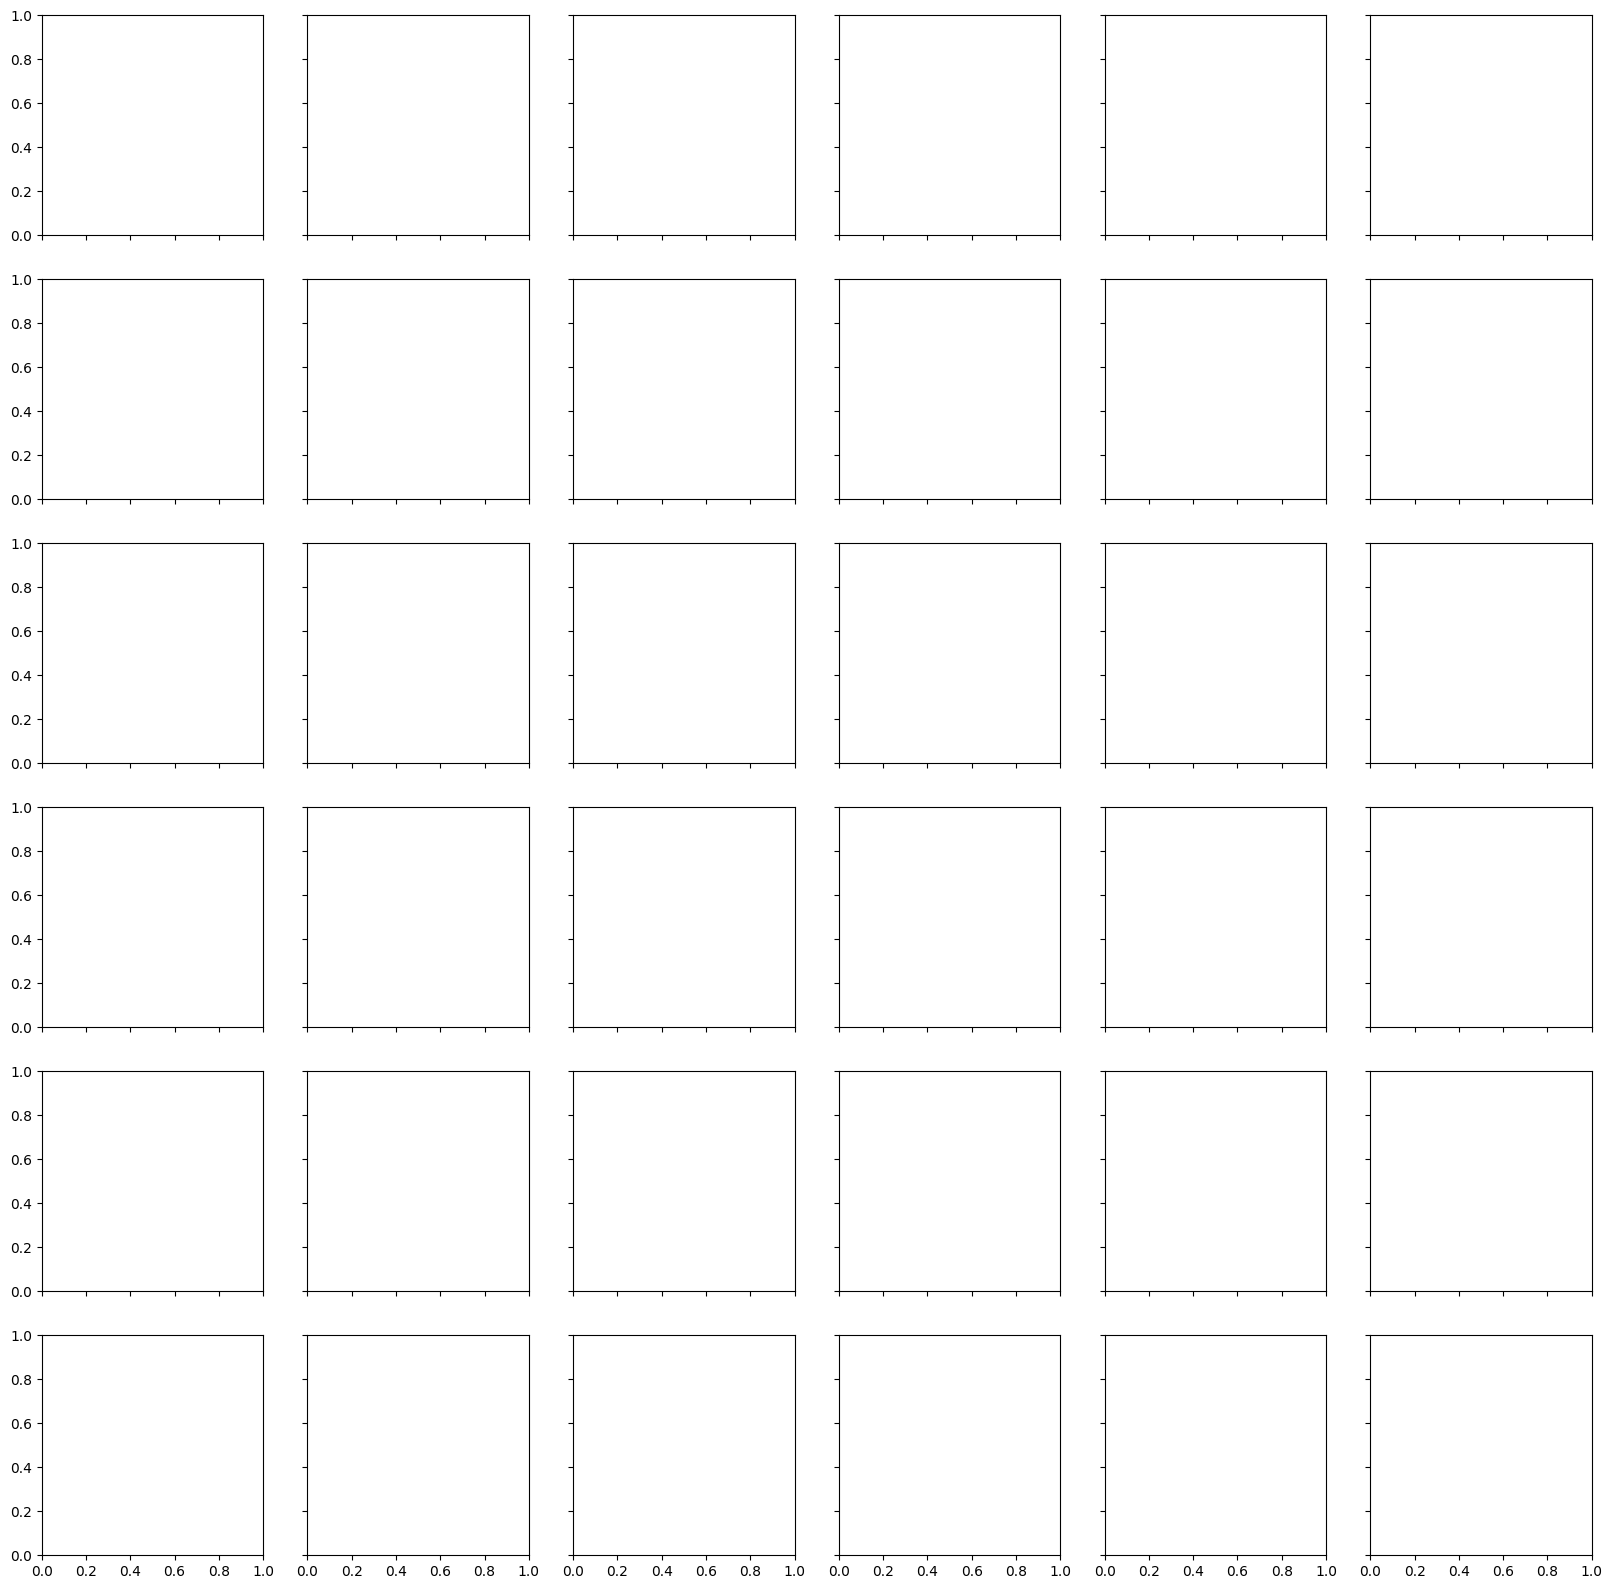

In [79]:
# plot correct samples
import numpy as np
fig, ax = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))
for i in range(6):
    for j in range(6):
        while True:
            idx = np.random.choice(ds_test.shape[0], 1, replace=False)
            if ds_test[int(idx[0])]["labels"] > 0 and ds_test[int(idx[0])]["labels"] == predlabels[int(idx[0])]:
                break
        s = ds_test[int(idx[0])]
        ax[i,j].imshow(np.transpose(s['pixel_values'], (1,2,0)))
        ax[i,j].set_title(f"G: {s['labels']}\nP: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')

plt.show()

ValueError: operands could not be broadcast together with shapes (2725,) (2725,7) 

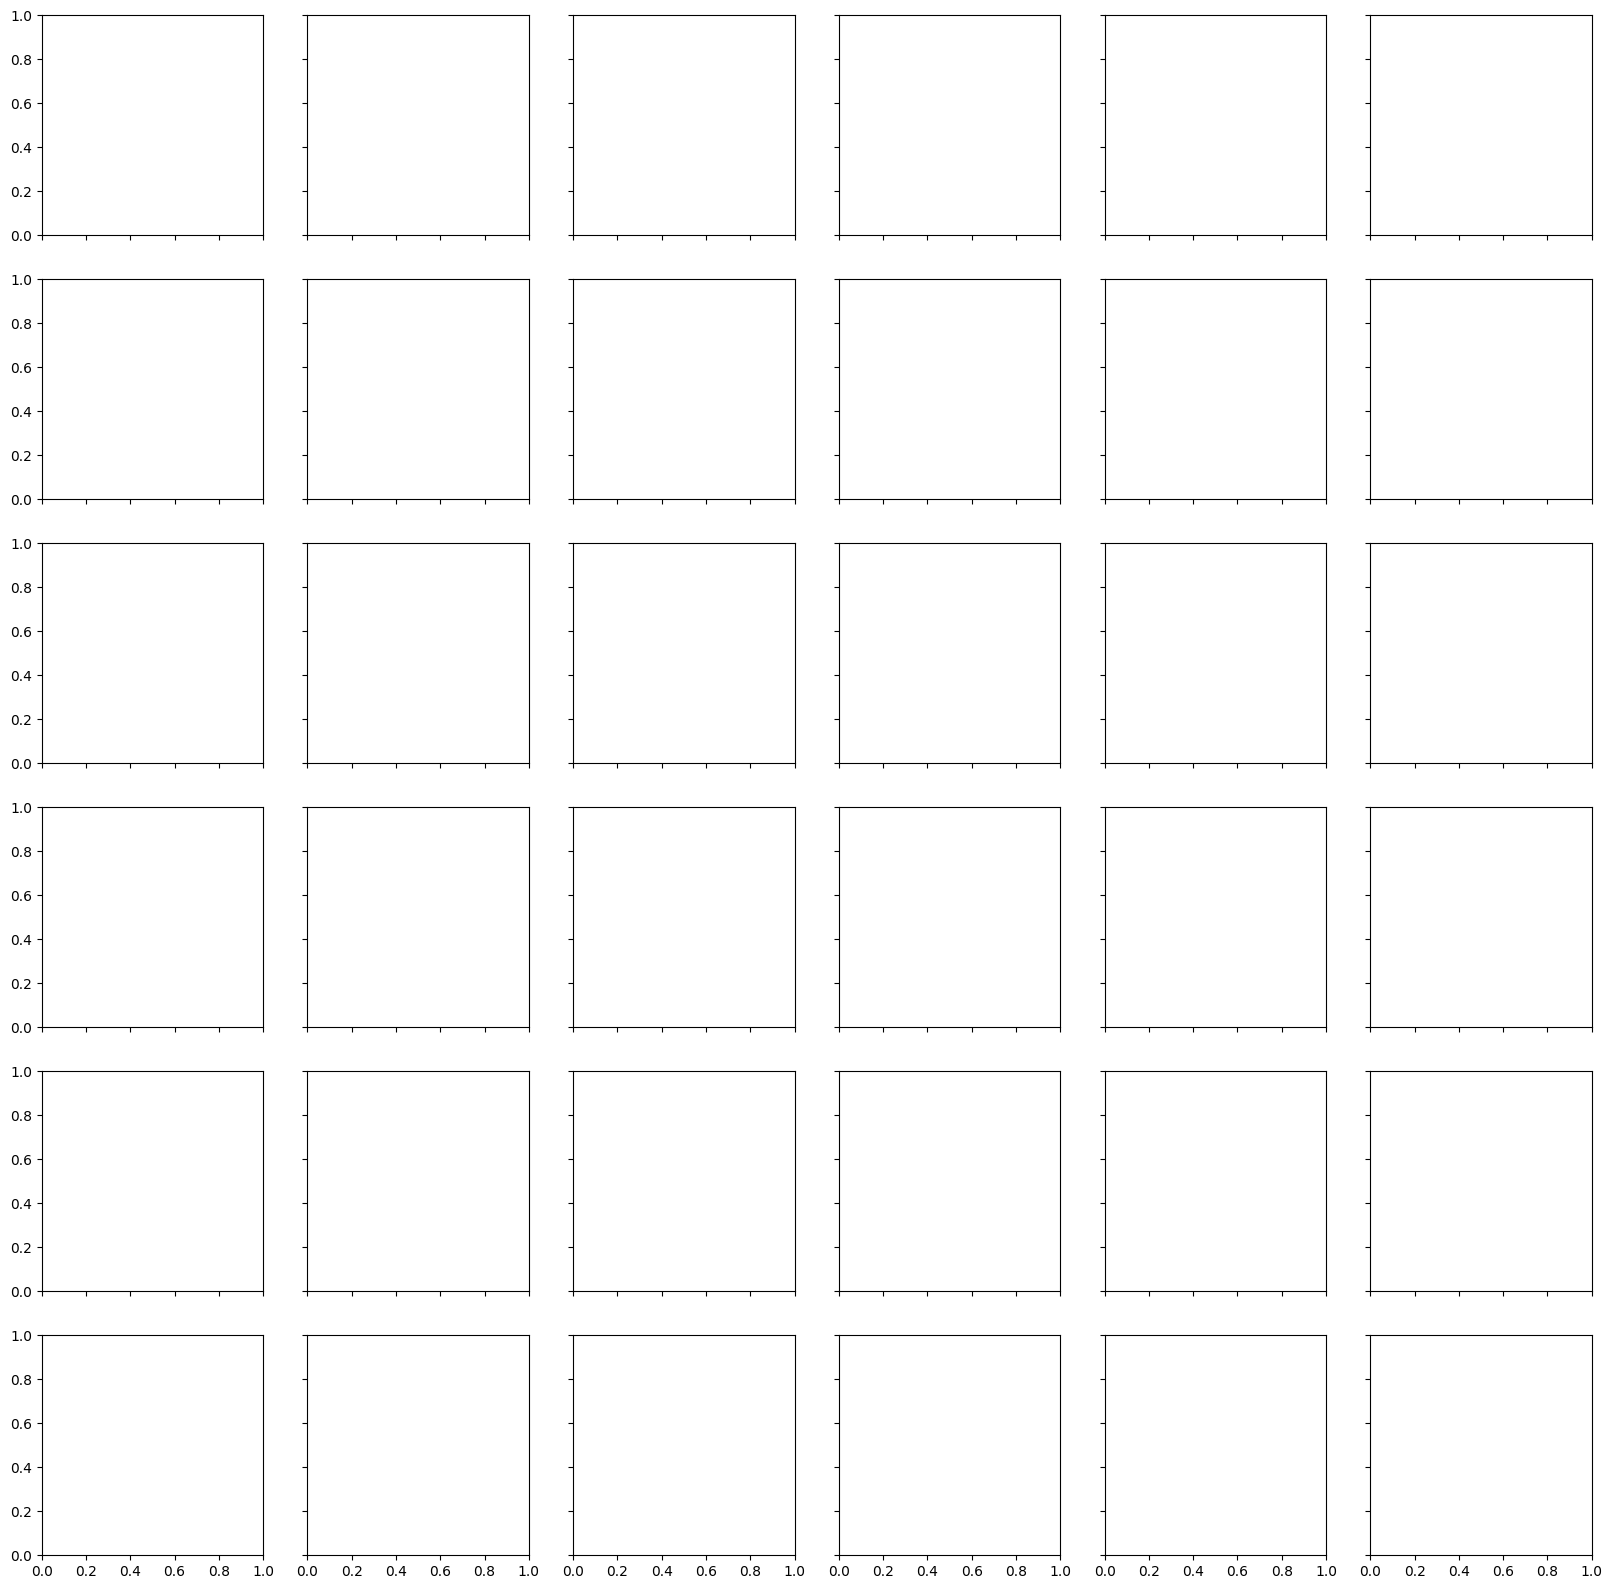

In [80]:
# plot wrong samples
idx = -1
fig, ax = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))
for i in range(6):
    for j in range(6):
        for id in np.where(ds_test['labels'] != predlabels)[0]:
            if id > idx:
                idx = int(id)
                break
        if idx > -1:
            s = ds_test[idx]
            ax[i,j].imshow(np.transpose(s['pixel_values'], (1,2,0)))
            ax[i,j].set_title(f"G: {s['labels']}\nP: {predlabels[idx]}")
            ax[i,j].axis('off')
plt.show()

# Duramat mono 3 (unlabeled)

In [ ]:
path_all = "/Users/eagle/Documents/eagle-labelling/features_pickle/Duramat_all_no_pool.pkl"
path_all_max = "/Users/eagle/Documents/eagle-labelling/features_pickle/Duramat_all_maxpool.pkl"
df_all = pd.read_pickle(path_all)
df_all_max = pd.read_pickle(path_all_max)
df_mono_3 = df_all.loc[df_all_max["technology"]=="mono_3"]
df_mono_3 = batch_transform(df_mono_3)
ds_mono_3 = Dataset.from_dict({
                "image": df_mono_3.pixel_values,
                "labels": np.zeros(df_mono_3.pixel_values.shape[0])
            })
ds_mono_3

Dataset({
    features: ['image', 'labels'],
    num_rows: 807
})

In [ ]:
predictions = trainer.predict(ds_mono_3)
predlabels = predictions.predictions.argmax(axis=-1)
predictions.metrics

{'test_loss': 0.2632761299610138,
 'test_accuracy': 0.9392812887236679,
 'test_f1': 0.9686900958466453,
 'test_runtime': 45.4231,
 'test_samples_per_second': 17.766,
 'test_steps_per_second': 1.123}

In [ ]:
np.sum(predlabels != 0)

49

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

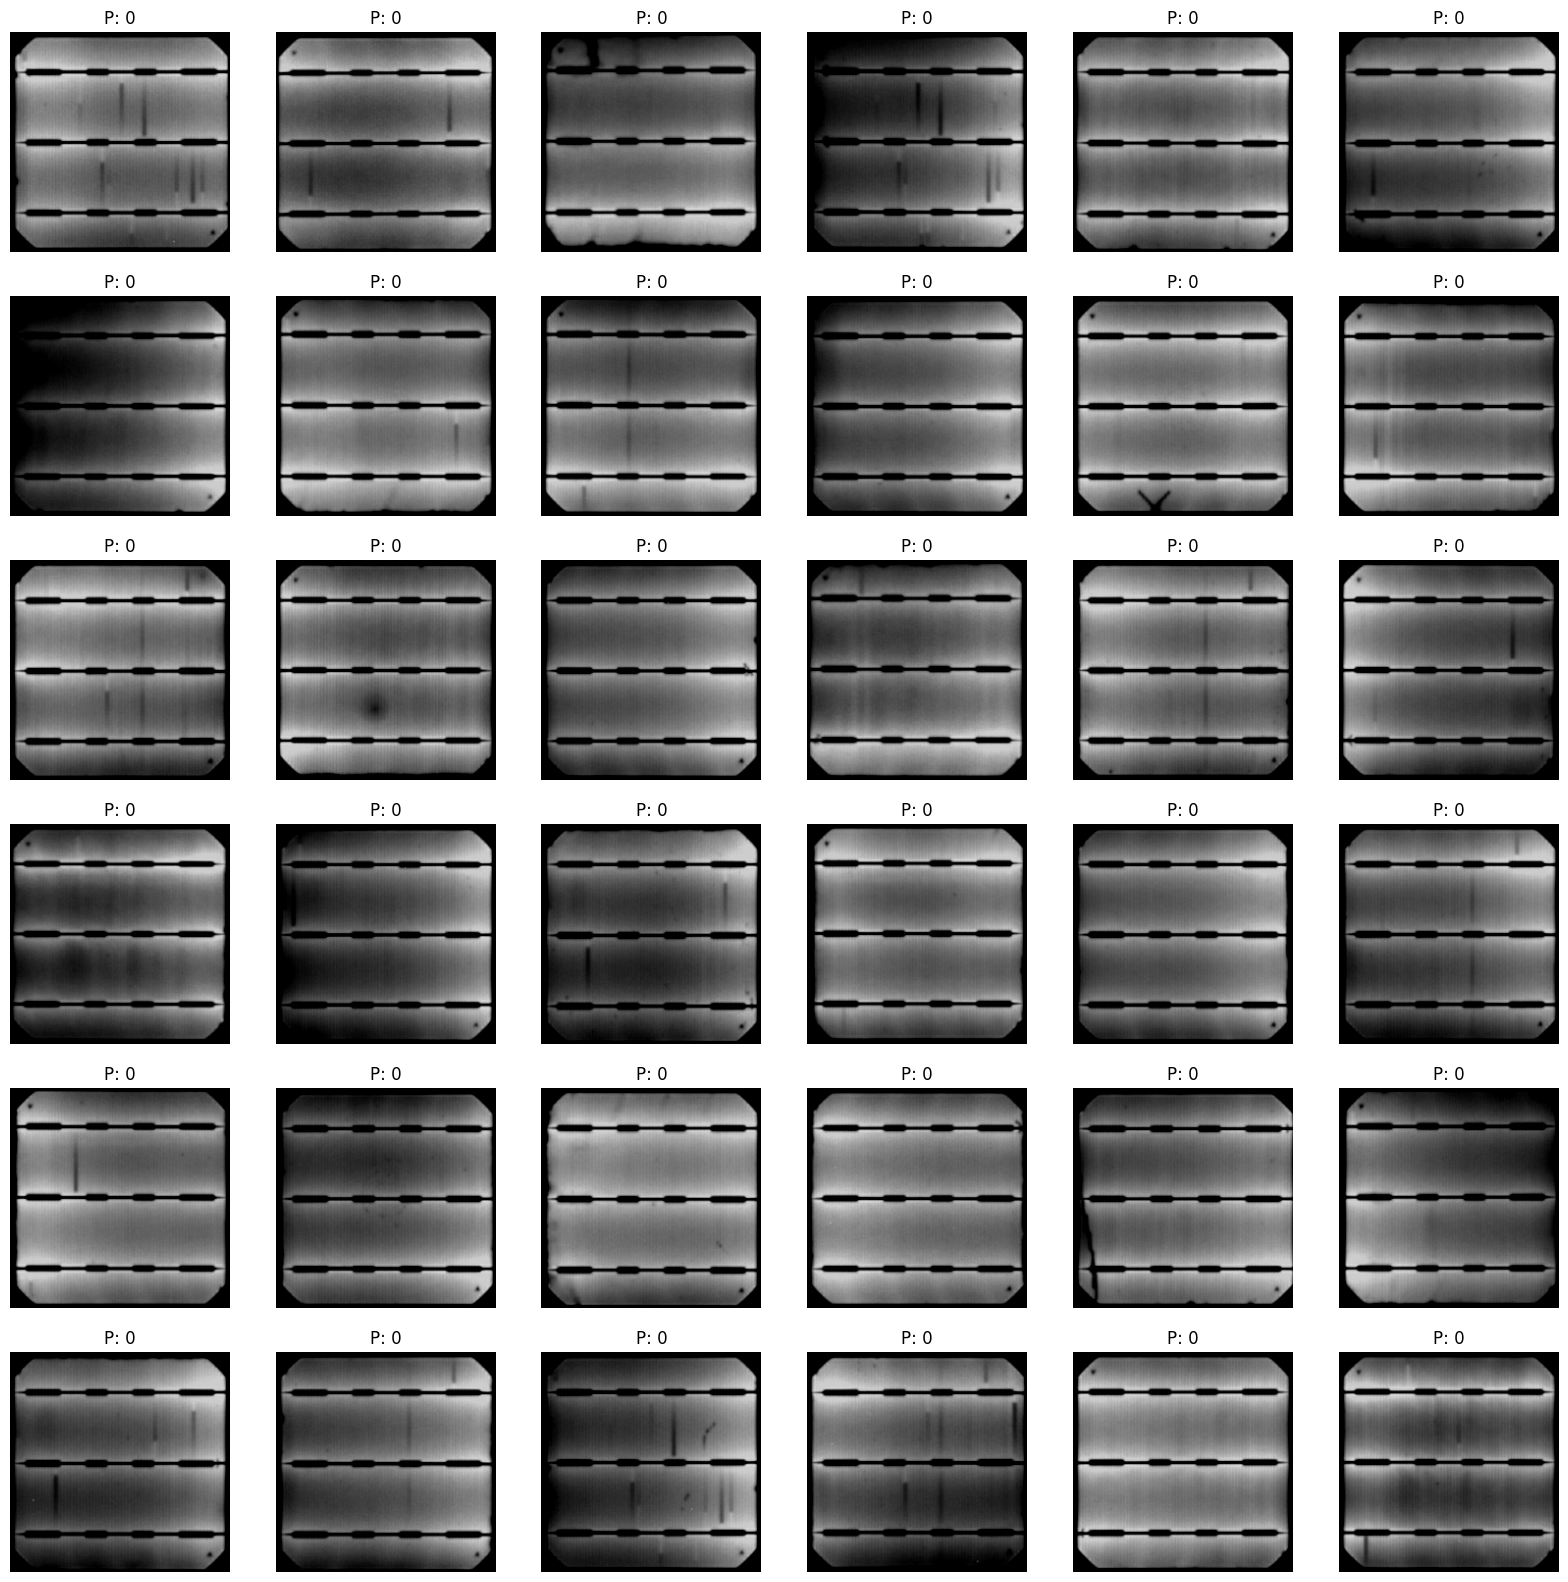

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(6):
        while True:
            idx = np.random.choice(ds_mono_3.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] == 0 and idx not in used:
                used.append(idx)
                break
        s = ds_mono_3[idx]
        ax[i,j].imshow(np.transpose(s['image'][0], (1,2,0)))
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

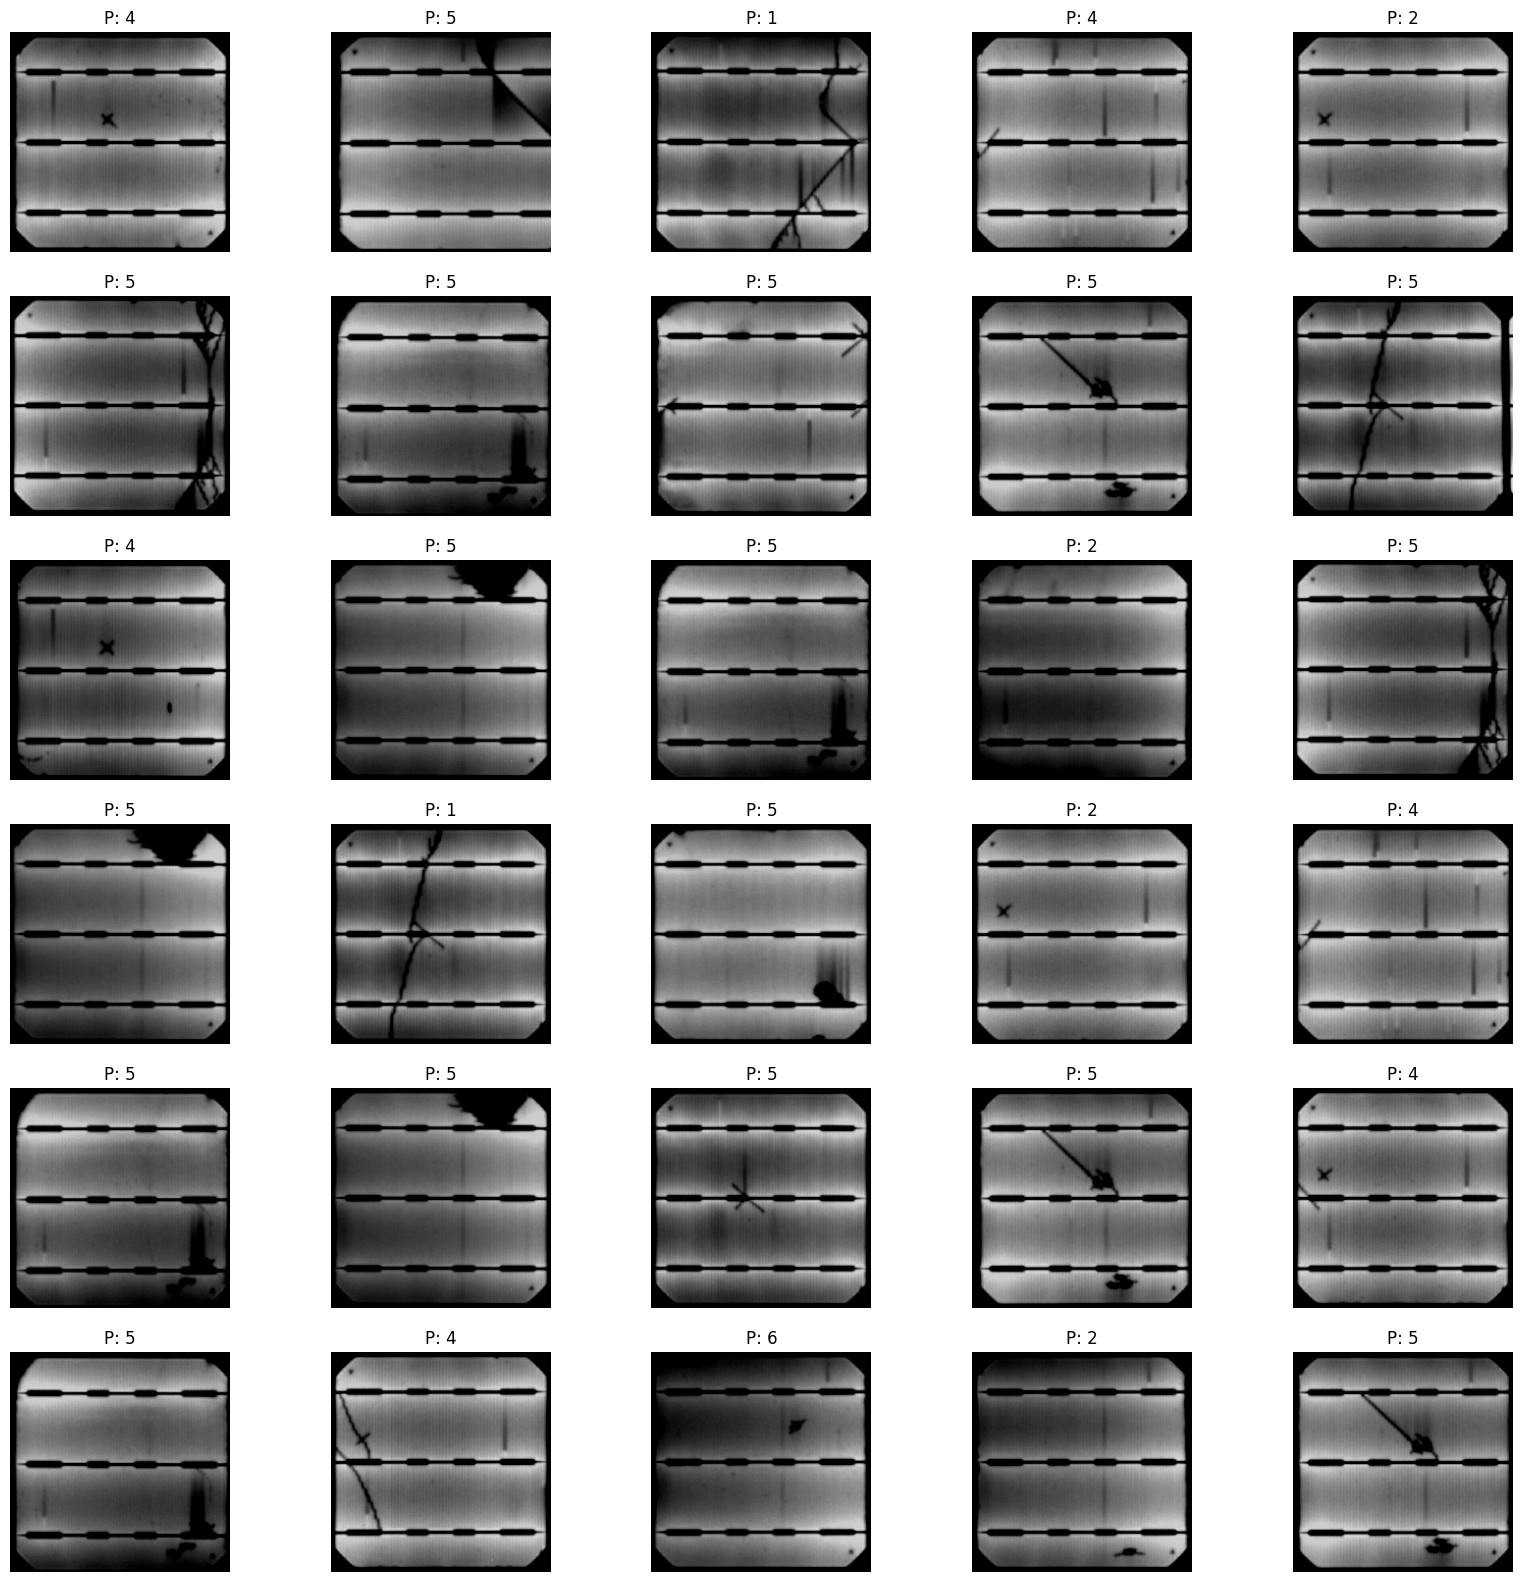

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 5, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(5):
        while True:
            idx = np.random.choice(ds_mono_3.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] > 0 and idx not in used:
                used.append(idx)
                break
        s = ds_mono_3[idx]
        ax[i,j].imshow(np.transpose(s['image'][0], (1,2,0)))
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()

# Duramat Mono4 (unlabeled)

In [ ]:
import tensorflow as tf

In [ ]:
def extract_original_images(tf_dataset : tf.data.Dataset) -> np.ndarray:
    '''
    Function for the unsupervised case.
    Extracts the original images from a tf Dataset and saves them into a numpy array for further processing (e.g. with UMAP)
    This function assumes that offset = 0 and crop_size = image_size if cropped == none
    This function assumes it is working with images and not features extracted from images.
    '''
    images = []
    for batch_images in tf_dataset:
            for im in batch_images:
                images.append(np.array(im).astype(int))
 
    return images
 
directory = "/Users/eagle/Library/CloudStorage/OneDrive-SharedLibraries-FFHS/eagle-bfe - data/Webpage/bboxes/duramat_mono4_big"
data_ds_mono4 = tf.keras.utils.image_dataset_from_directory(
            directory=directory,
            labels=None,
            batch_size=128,
            #image_size=image_size,
            seed=42,
            #subset= subset,
            #validation_split=validation_split,
            shuffle = False)
 
original_images = extract_original_images(data_ds_mono4)
 
df_mono_4 = pd.DataFrame(data = {"images" : original_images, "labels": np.zeros(len(original_images))})

df_mono_4 = batch_transform(df_mono_4)
ds_mono_4 = Dataset.from_dict({
                "image": df_mono_4.pixel_values,
                "labels": np.zeros(df_mono_4.pixel_values.shape[0])
            })
ds_mono_4


Found 10620 files.


2024-11-28 16:10:48.366306: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Ultra
2024-11-28 16:10:48.366341: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2024-11-28 16:10:48.366346: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 48.00 GB
2024-11-28 16:10:48.366545: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-28 16:10:48.366566: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2024-11-28 16:11:02.346751: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Dataset({
    features: ['image', 'labels'],
    num_rows: 10620
})

In [ ]:
predictions = trainer.predict(ds_mono_4)
predlabels = predictions.predictions.argmax(axis=-1)
predictions.metrics

{'test_loss': 0.41850829124450684,
 'test_accuracy': 0.901412429378531,
 'test_f1': 0.9481503491308869,
 'test_runtime': 578.0253,
 'test_samples_per_second': 18.373,
 'test_steps_per_second': 1.149}

In [ ]:
np.sum(predlabels != 0)

1047

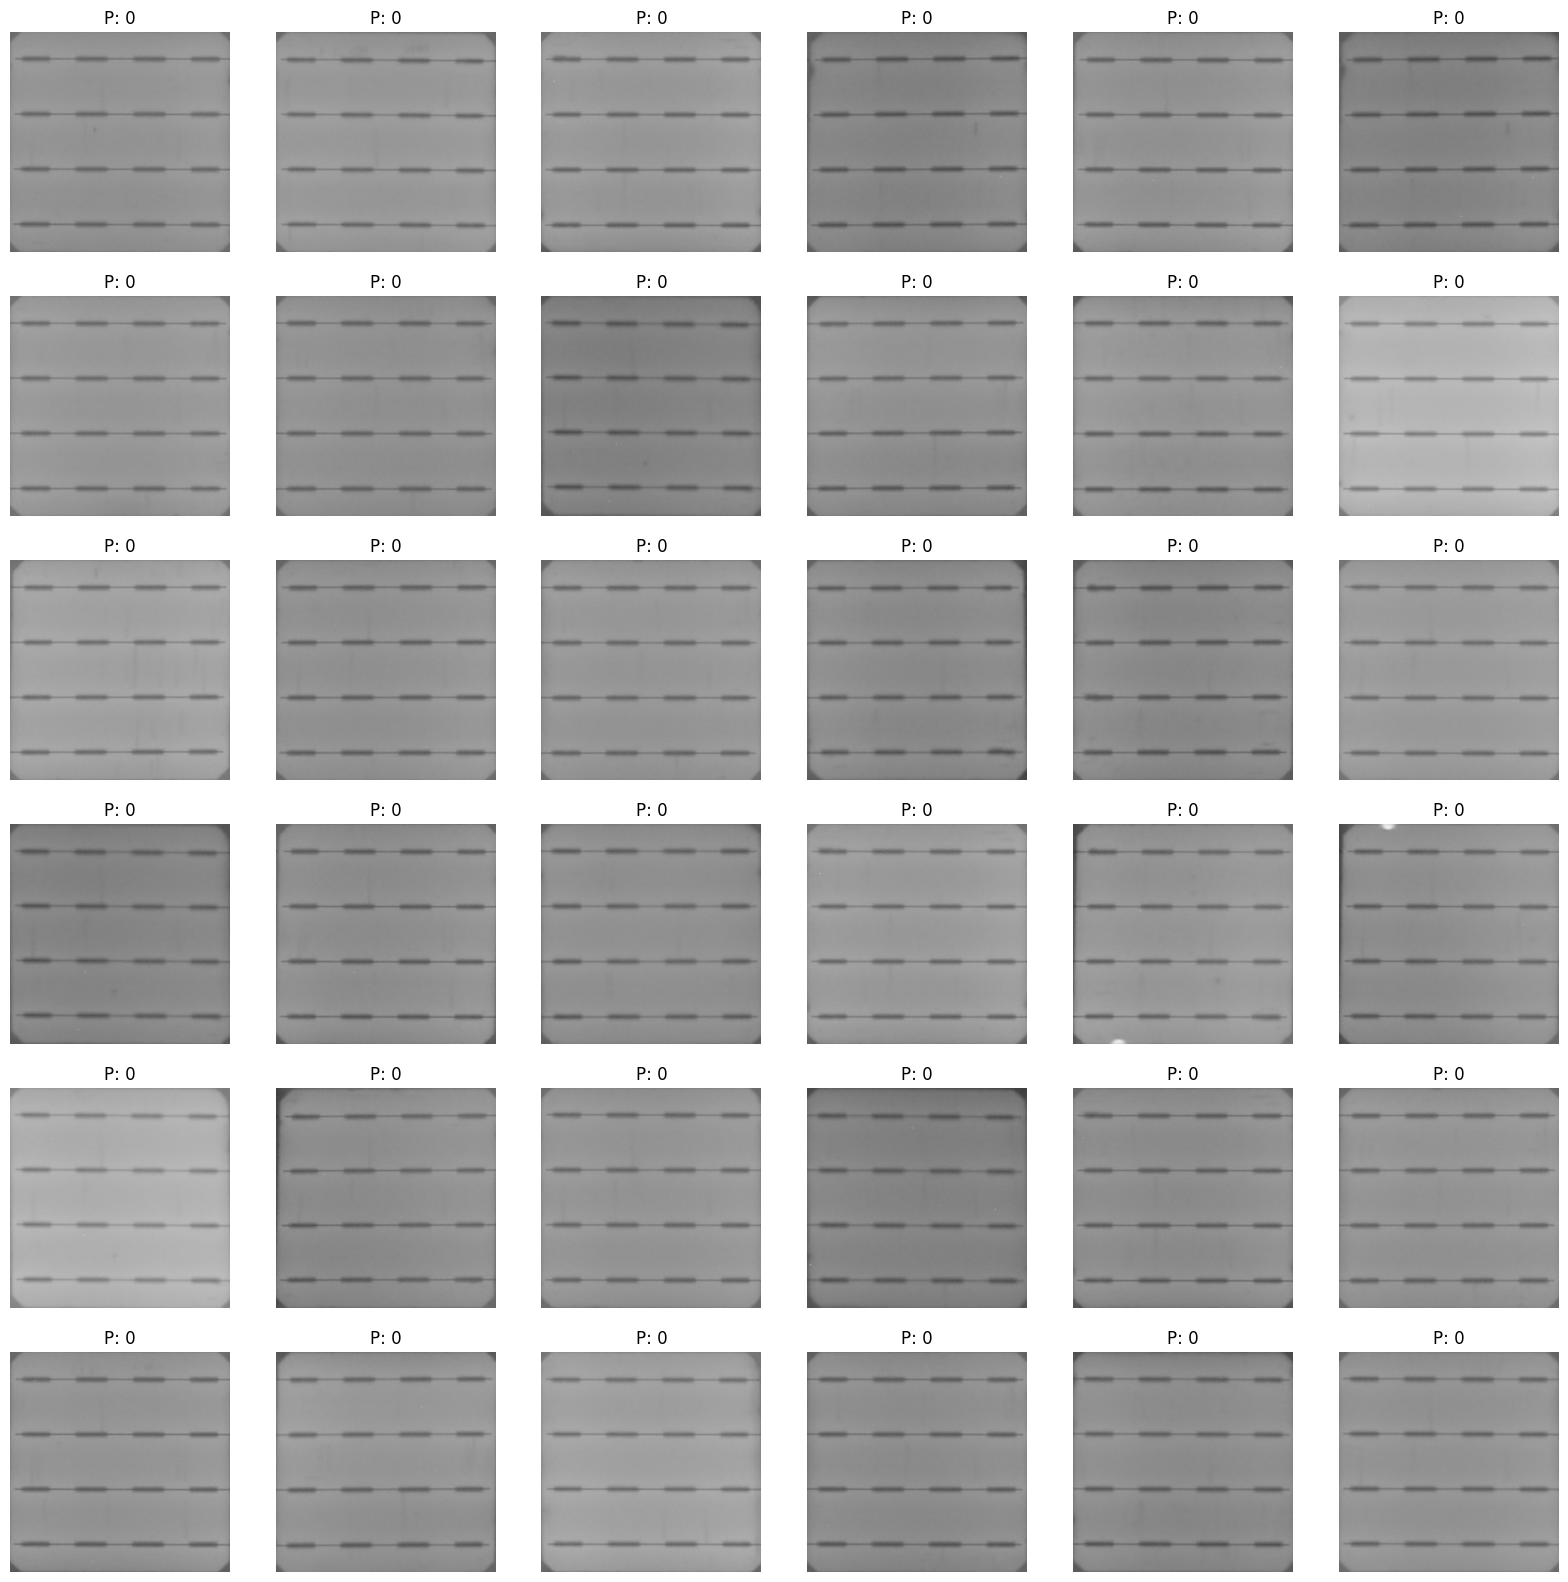

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(6):
        while True:
            idx = np.random.choice(ds_mono_4.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] == 0 and idx not in used:
                used.append(idx)
                break
        s = original_images[int(idx[0])]
        ax[i,j].imshow(s)
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()

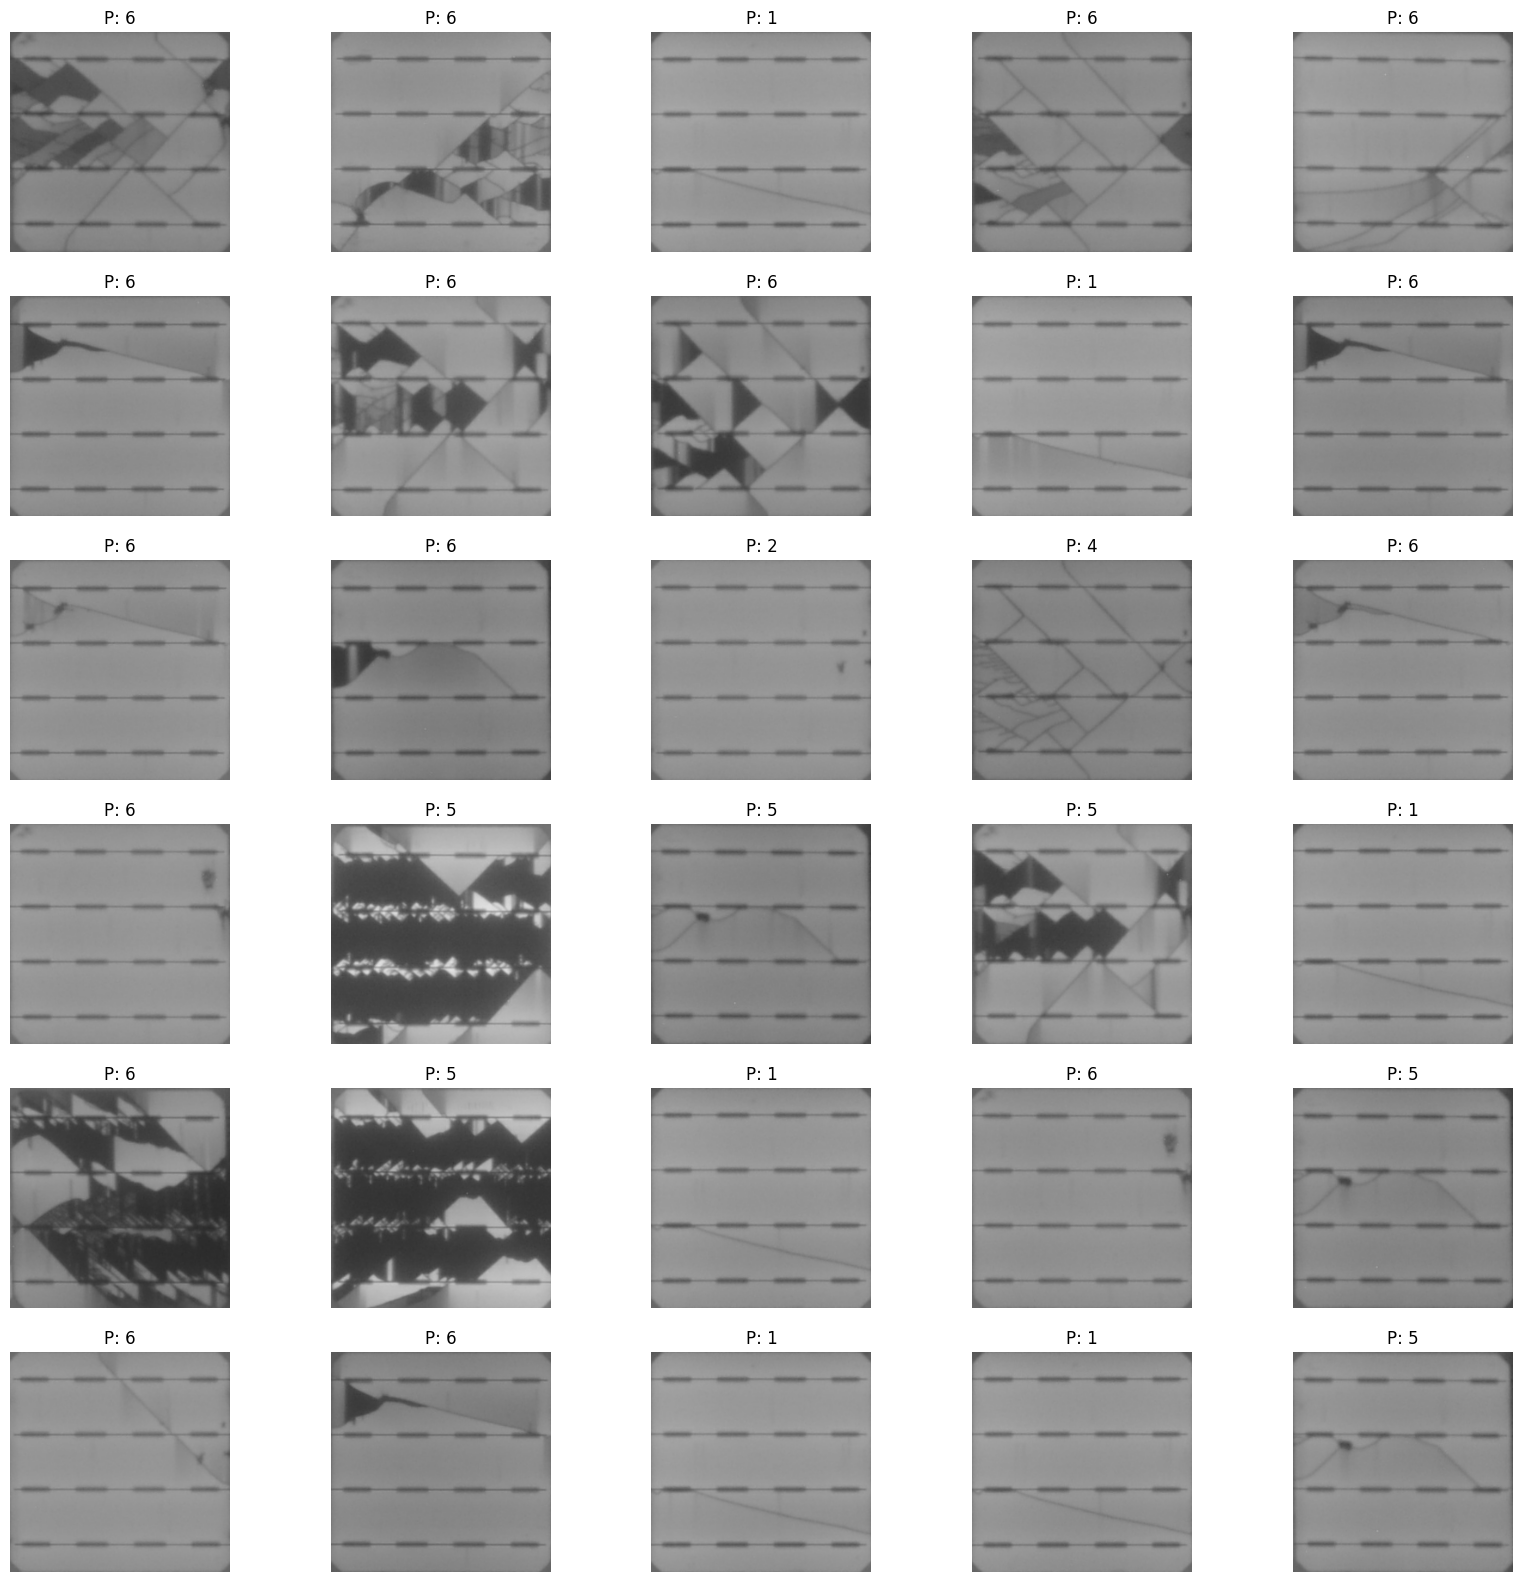

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 5, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(5):
        while True:
            idx = np.random.choice(ds_mono_4.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] > 0 and idx not in used:
                used.append(idx)
                break
        s = original_images[int(idx[0])]
        ax[i,j].imshow(s)
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()

# TISO (unlabeled)

In [ ]:
import os
directory = "/Users/eagle/Library/CloudStorage/OneDrive-SharedLibraries-FFHS/eagle-bfe - data/Webpage/bboxes/TISO-EAGLE-23-P09_images"
def decode_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_tiff(img, channels=3)  # Adjust channels as necessary
    img = tf.image.resize(img, [256, 256])  # Resize to desired dimensions
    return img

# Function to process the dataset
def process_path(file_path):
    label = tf.strings.split(file_path, os.path.sep)[-2]
    img = decode_img(file_path)
    return img, label

def LoadTiffDS(directory):
# Create dataset from directory
    data_ds = tf.data.Dataset.list_files(os.path.join(directory, '*/*.tif'))
    data_ds = data_ds.map(process_path, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    # Shuffle and batch the dataset
    data_ds = data_ds.shuffle(buffer_size=1000)
    data_ds = data_ds.batch(batch_size=128)
    data_ds = data_ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return data_ds

data_ds_tiso = LoadTiffDS(directory)
 
original_images = extract_original_images(data_ds_tiso)
 
df_tiso = pd.DataFrame(data = {"pixel_value" : original_images, "labels": np.zeros(len(original_images))})

df_tiso = batch_transform(df_tiso)
ds_tiso = Dataset.from_dict({
                "image": df_tiso.pixel_values,
                "labels": np.zeros(df_tiso.pixel_values.shape[0])
            })
ds_tiso

In [ ]:
predictions = trainer.predict(ds_tiso)
predlabels = predictions.predictions.argmax(axis=-1)
predictions.metrics

In [ ]:
np.sum(predlabels == 0)

In [ ]:
np.sum(predlabels != 0)

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(6):
        while True:
            idx = np.random.choice(ds_tiso.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] == 0 and idx not in used:
                used.append(idx)
                break
        s = original_images[int(idx[0])]
        ax[i,j].imshow(s)
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()

In [ ]:
# plot samples
import numpy as np
fig, ax = plt.subplots(6, 5, sharex=True, sharey=True, figsize=(20,20))
used = []
for i in range(6):
    for j in range(5):
        while True:
            idx = np.random.choice(ds_tiso.shape[0], 1, replace=False)
            if predlabels[int(idx[0])] > 0 and idx not in used:
                used.append(idx)
                break
        s = original_images[int(idx[0])]
        ax[i,j].imshow(s)
        ax[i,j].set_title(f"P: {predlabels[int(idx[0])]}")
        ax[i,j].axis('off')
plt.show()